In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [4]:
df.isnull().sum().sum()

np.int64(0)

In [5]:
df.duplicated().sum()

np.int64(1081)

In [6]:
df = df.drop_duplicates()

In [7]:
df.shape

(283726, 31)

In [8]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

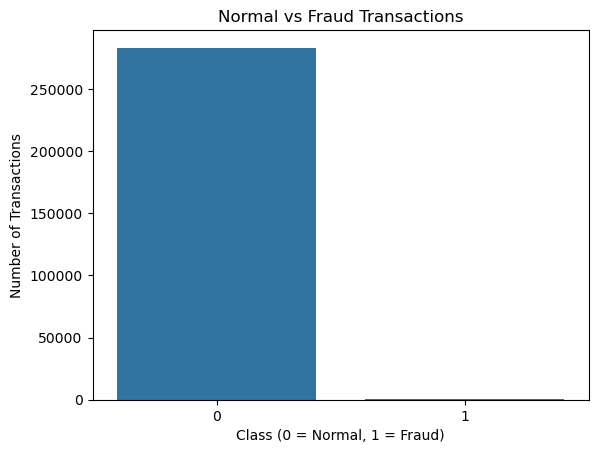

In [9]:
sns.countplot(data=df, x="Class")
plt.title("Normal vs Fraud Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

In [10]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (283726, 30)
Target: (283726,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (226980, 30)
Testing data: (56746, 30)


In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [15]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
y_pred = model.predict(X_test)

In [17]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


In [18]:
print("Logistic Regression Results")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Logistic Regression Results
Accuracy : 0.9753
Precision: 0.0564
Recall   : 0.8737
F1 Score : 0.1059


In [19]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



In [20]:
test1 = [
    406.0, -1.359807, -0.072781, 2.536347, 1.378155,
    -0.338321, 0.462388, 0.239599, 0.098698, 0.363787,
    0.090794, -0.551600, -0.617801, -0.991390, -0.311169,
    1.468177, -0.470400, 0.207971, 0.025791, 0.403993,
    0.251412, -0.018307, 0.277838, -0.110474, 0.066928,
    0.128539, -0.189115, 0.133558, -0.021053, 149.62
]

test2 = [
    406.0, -2.312227, 1.951992, -1.609851, 3.997906,
    -0.522188, -1.426545, -2.537387, 1.391657, -2.770089,
    -2.772272, 3.202033, -2.899907, -0.595222, -4.289254,
    0.389724, -1.140108, -2.830055, -0.016822, 0.416956,
    0.126911, 0.517232, -0.035049, -0.465211, 0.320198,
    0.044519, 0.177839, 0.261145, -0.143276, 0.00
]

for transaction in [test1, test2]:
    input_data = pd.DataFrame([transaction], columns=X.columns)
    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)[0]

    print("Prediction:", "FRAUD" if prediction == 1 else "NORMAL")

Prediction: NORMAL
Prediction: FRAUD


In [23]:
test3 = [
    1.0, 1.191857, 0.266151, 0.166480, 0.448154,
    0.060018, -0.082361, -0.078803, -0.085102, -0.255425,
    -0.166974, 1.612727, 1.065235, 0.489095, -0.143772,
    0.635558, 0.463917, -0.114805, -0.183361, -0.145783,
    -0.069083, -0.225775, -0.638672, 0.101288, -0.339846,
    0.167170, 0.125895, -0.008983, 0.014724, 2.69
]

test4 = [
    2.0, -1.358354, -1.340163, 1.773209, 0.379780,
    -0.503198, 1.800499, 0.791461, 0.247676, -1.514654,
    0.207643, 0.624502, 0.066084, 0.717293, -0.165946,
    2.345865, -1.184340, 0.072650, -0.138333, -0.503292,
    0.251120, 0.274650, -0.110474, 0.066928, 0.128539,
    -0.189115, 0.133558, -0.021053, 0.00, 378.66
]

for transaction in [test3, test4]:
    input_data = pd.DataFrame([transaction], columns=X.columns)
    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)[0]
    print("Prediction:", "FRAUD" if prediction == 1 else "NORMAL")

Prediction: NORMAL
Prediction: NORMAL


In [24]:
test5 = [
    406.0, -2.312227, 1.951992, -1.609851, 3.997906,
    -0.522188, -1.426545, -2.537387, 1.391657, -2.770089,
    -2.772272, 3.202033, -2.899907, -0.595222, -4.289254,
    0.389724, -1.140108, -2.830055, -0.016822, 0.416956,
    0.126911, 0.517232, -0.035049, -0.465211, 0.320198,
    0.044519, 0.177839, 0.261145, -0.143276, 0.00
]

test6 = [
    467.0, -3.043540, -3.157307, 1.088463, 2.288644,
    1.359805, -1.064823, 0.325574, -0.067794, -0.270953,
    -0.838587, -0.414575, 0.702871, -0.133080, -0.379536,
    -0.068603, -0.474860, -0.871088, -0.511713, -0.406019,
    -0.286716, 1.109969, -0.425063, 0.110468, -0.167593,
    -0.381963, -0.142018, -0.137469, 0.00, 529.00
]

for transaction in [test5, test6]:
    input_data = pd.DataFrame([transaction], columns=X.columns)
    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)[0]
    print("Prediction:", "FRAUD" if prediction == 1 else "NORMAL")

Prediction: FRAUD
Prediction: FRAUD
